# 09 · Does the "€100 → Gold tier" perk retain people? — RDD (CausalPy)

> **Runs in the `legacy` environment (pymc<6): `make env-legacy`, kernel `cmp-legacy`.**

**The business decision.** Customers who cross **€100** annual spend get **Gold** status and its perks.
Gold members retain better — but of course they do, they're big spenders. Does the *perk itself* boost
retention, or are we just seeing that big spenders would retain anyway? And where should we set the
threshold?

### The idea: a sharp rule creates a natural experiment

**Regression discontinuity (RDD)** exploits the fact that Gold status is assigned by a **sharp rule** on a
**running variable** (annual spend): below €100 you're out, at €100-or-above you're in. Now compare a
customer at €99.50 with one at €100.50. On *retention potential* they are essentially identical — nobody
is meaningfully more loyal for having spent one euro more. The *only* thing that differs between them is
that one got the perk and one didn't. So **any jump in retention exactly at €100** must be caused by the
perk, not by the underlying "big spenders retain more" trend (which is smooth through the cutoff). RDD
reads off the size of that jump.

### What it can and can't tell you

- It estimates a **Local Average Treatment Effect (LATE) at the cutoff** — the perk's effect *for customers right at the €100 margin*. *Local* means local-to-the-cutoff: an average effect that holds only for that slice of customers, as opposed to an **Average Treatment Effect (ATE)** over everyone. It says nothing
  about your €500 whales; don't extrapolate the jump to them. (Step 3 makes 'local' precise and contrasts it with the *fuzzy* design, where crossing €100 only nudges the *probability* of Gold rather than flipping it.)
- It's only valid if customers can't **manipulate** their spend to just clear €100 (that would make the
  people just above and just below systematically different). We test this with a **simplified McCrary-style** density check (a symmetric-window binomial test for a suspicious
  pile-up of customers just above the cutoff; the full McCrary 2008 test fits a local-linear density with a Wald SE).
- A headline RD number is only as good as its **robustness checks**: does the jump survive different
  **bandwidths** (how wide a window around €100 we use), **placebo cutoffs** (fake thresholds should show
  no jump), and **polynomial order** (linear vs curved fits)? We run all of them.

> **On real data.** RDD fits anywhere a **threshold rule** assigns a treatment: loyalty tiers, credit-score
> cutoffs for an offer, "spend €X for free shipping," scholarship/eligibility scores. You need the running
> variable, the cutoff, and the outcome — all of which live in your CRM.

It follows the repo's fixed **7-step contract**: question → simulate → identify → estimate → validate → decide in € → caveats.


In [1]:
import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
import causalpy as cp
from cmp import dgp, estimators as est, plots
plots.use_style()
FAST = os.environ.get("CMP_FAST", "1") == "1"
SEED = 29; CUTOFF = 100.0; TRUE = 0.14

## 2 · Simulate a ground truth

Retention rises smoothly with annual spend (big spenders retain more anyway) — **plus** a true
**+14pp jump** exactly at €100 from the Gold perk. The smooth part is the confounder; the jump is
the causal effect. Spend is concentrated around the cutoff so both sides are well-populated.

**The data-generating model** — exactly what `dgp.rdd_perk` implements (defaults & seed in
`src/cmp/dgp.py`). $n = 2000$ customers, cutoff $c = 100$:

$$
S \sim \mathcal N(100,\, 40^{2}) \;\text{(clipped below at 1)}, \qquad
D = \mathbf 1[S \ge 100],
$$
$$
p(S) = \operatorname{clip}\Big(\underbrace{0.45 + 0.0015\,(S - 100)}_{\text{smooth baseline}}
  \;+\; \underbrace{0.14\, D}_{\text{the jump}},\; 0.02,\; 0.98\Big),
\qquad Y = \text{retained} \sim \text{Bernoulli}\big(p(S)\big).
$$

The smooth term $0.0015\,(S-100)$ is "big spenders retain more anyway" — the trend that fools the
naive Gold-vs-non-Gold comparison but passes *continuously* through the cutoff (it is deliberately
**linear**, so a local-linear fit is unbiased and the robustness section can vary bandwidth and
polynomial order against a clean benchmark). The $0.14\,D$ term is the perk's true +14pp causal
jump. Centering spend on the cutoff ($S \sim \mathcal N(100, 40^{2})$) keeps both sides of the
threshold densely populated.


In [2]:
df, true_jump = dgp.rdd_perk(n=2500, cutoff=CUTOFF, true_jump=TRUE, seed=SEED)
df["treated"] = df["treated"].astype(int)
print(f"TRUE perk effect = +{true_jump:.0%} retention at €{CUTOFF:.0f}  ·  {(df.spend>=CUTOFF).mean():.0%} are Gold")
df.head()

TRUE perk effect = +14% retention at €100  ·  50% are Gold


,spend,treated,retention
0,84.325206,0,1.0
1,101.996816,1,0.0
2,93.392393,0,1.0
3,93.281224,0,0.0
4,102.504635,1,0.0


### 2b · First, watch the naive comparison fail

The obvious analysis — the one every loyalty dashboard already shows — is *average retention of Gold
members vs everyone else*. Before fixing it, let's compute it and see exactly **how** wrong it is.
Because we wrote the DGP, we can decompose the naive gap in closed form. Write $\Delta = S - c$
(spend centered on the cutoff) and $D = \mathbf 1[\Delta \ge 0]$; then

$$
\underbrace{\mathbb E[Y \mid D{=}1] - \mathbb E[Y \mid D{=}0]}_{\text{naive Gold-vs-rest gap}}
\;=\; \underbrace{0.14}_{\text{true jump}}
\;+\; \underbrace{0.0015\,\big(\mathbb E[\Delta \mid \Delta \ge 0]
 - \mathbb E[\Delta \mid \Delta < 0]\big)}_{\text{selection: Gold members are big spenders}}.
$$

With $\Delta \sim \mathcal N(0, 40^{2})$, each one-sided mean is $40\sqrt{2/\pi} \approx 31.9$
in absolute value (the average distance from the mean on one side of a mean-zero Normal is $\sigma\sqrt{2/\pi}$), so the selection term is $0.0015 \times 2 \times 31.9 \approx +9.6$pp (spend
and probability clipping make this slightly approximate). Roughly **+10pp of pure selection** stacked
on top of the +14pp causal jump — the naive gap credits the perk with the whole "big spenders retain
anyway" trend. That +10pp is exactly what RDD will subtract off by comparing customers only *at the
margin*, where the selection term vanishes.

In [3]:
naive = df.loc[df.treated == 1, "retention"].mean() - df.loc[df.treated == 0, "retention"].mean()
pred_selection = 0.0015 * 2 * 40 * np.sqrt(2 / np.pi)     # closed-form selection term (pre-clipping)
print(f"Naive Gold-vs-rest gap: {naive:+.1%}   =   true causal jump +{TRUE:.0%}   +   selection bias {naive - TRUE:+.1%}")
print(f"(closed-form prediction of the selection term: +{pred_selection:.1%}; the small remainder is clipping + sampling noise)")
print("The naive dashboard number nearly doubles the perk's true effect — pure 'big spenders retain anyway' selection.")

Naive Gold-vs-rest gap: +23.9%   =   true causal jump +14%   +   selection bias +9.9%
(closed-form prediction of the selection term: +9.6%; the small remainder is clipping + sampling noise)
The naive dashboard number nearly doubles the perk's true effect — pure 'big spenders retain anyway' selection.


## 3 · Identify — a jump at the cutoff is causal (and its validity conditions)

**Potential outcomes.** Let $Y_i(1)$ and $Y_i(0)$ be customer $i$'s retention *with* and *without*
the perk, $S_i$ the running variable (annual spend), and $D_i = \mathbf 1[S_i \ge c]$ the sharp
assignment rule at the cutoff $c$ (here €100). The **estimand** — the exact quantity we're trying to pin down — is the perk's effect **for
customers at the margin**:

$$
\tau_{RD} \;=\; \mathbb E\big[Y(1) - Y(0) \,\big|\, S = c\big].
$$

**Assumption (continuity).** The conditional means $x \mapsto \mathbb E[Y(d) \mid S = x]$ are
*continuous at* $c$ for $d \in \{0, 1\}$. In words: **nothing else that drives retention jumps at
€100** — loyalty, tenure, customer quality all pass smoothly through the threshold; the perk is the
only thing that switches. Then the observed jump identifies $\tau_{RD}$ in two steps ($x \downarrow c$ means spend approaching €100 from *above*, $x \uparrow c$ from *below*):

$$
\begin{aligned}
&\lim_{x \downarrow c} \mathbb E[Y \mid S{=}x] - \lim_{x \uparrow c} \mathbb E[Y \mid S{=}x] \\
&\quad=\; \lim_{x \downarrow c} \mathbb E[Y(1) \mid S{=}x] - \lim_{x \uparrow c} \mathbb E[Y(0) \mid S{=}x] \\
&\quad=\; \mathbb E[Y(1) \mid S{=}c] - \mathbb E[Y(0) \mid S{=}c] \;=\; \tau_{RD}.
\end{aligned}
$$

First equality: just above the cutoff every customer is treated, so the observed $Y$ *is* $Y(1)$;
just below, it *is* $Y(0)$. Second equality: continuity lets each one-sided limit converge to its
value *at* $c$. So the observable jump in average retention at €100 **equals** the causal effect at
€100 — we don't need to *assume away* hidden confounders or model who selects into treatment (the machinery of the earlier notebooks); the sharp rule plus continuity does all the work.
The price is *locality*: this is a **LATE at the cutoff** — an ATE exactly at €100, silent about
your €500 whales.

**Manipulation is a continuity violation — and it leaves fingerprints.** If customers (or account
managers) sort across the threshold — nudging a €97 basket to €101 — the *kind* of customer just
above €100 differs from the kind just below, so $\mathbb E[Y(d) \mid S = x]$ becomes
*discontinuous* at $c$ and the derivation collapses. Continuity itself is untestable (it's about
potential outcomes), but sorting leaves observable fingerprints, which gives us two **testable
implications**: the *density* of spend should be smooth at €100 (the McCrary check, 3b), and
*pre-determined covariates* should be smooth at €100 (the balance check, 3c). They can't prove
continuity; they can catch it failing.

**Sharp vs fuzzy — where this design sits.** Here the rule is *sharp*: $P(D{=}1 \mid S{=}x)$ jumps
from 0 to 1 at €100. When the rule is leaky (grandfathered members, manual overrides), crossing the
threshold only *raises the probability* of Gold, and the estimand becomes the **fuzzy-RD** ratio

$$
\tau_{\text{fuzzy}} \;=\;
\frac{\lim_{x \downarrow c} \mathbb E[Y \mid S{=}x] - \lim_{x \uparrow c} \mathbb E[Y \mid S{=}x]}
     {\lim_{x \downarrow c} \mathbb E[D \mid S{=}x] - \lim_{x \uparrow c} \mathbb E[D \mid S{=}x]}
$$

— the outcome jump rescaled by the treatment-probability jump. That ratio is exactly a **Wald/IV
estimator** — where an *instrument* is a variable that nudges who gets treated but affects the outcome only *through* that treatment; here "crossed the €100 threshold" is the instrument (full treatment in notebook 11) — and it identifies a
*complier*-LATE at the cutoff: the effect for customers whose Gold status actually flips when they
cross €100. In our sharp design the denominator is 1 and $\tau_{\text{fuzzy}}$ collapses to
$\tau_{RD}$ — which is the precise sense in which "local" here means local-to-the-cutoff, *not*
complier-local. Two things must hold for the sharp analysis, both checked below:

- **No manipulation** of the running variable at the cutoff — the McCrary-style density check (3b)
  plus covariate continuity (3c).
- **The functional form isn't driving the jump** — bandwidth, placebo cutoffs, and polynomial order
  (Step 5).


## 3b · Validity check 1 — McCrary-style density check (manipulation)

If customers game their spend to just clear €100 (or the business nudges them), the *density* of
spend jumps at the cutoff and RD breaks. We compare the density just below vs just above with a symmetric-window binomial test. (This is a
*simplified* version; the full McCrary 2008 test fits a local-linear density on each side with a formal standard error on the density gap.)
This is the first of the two testable implications of continuity derived in Step 3; the second —
pre-determined covariates must not jump — follows in 3c.


density just below 23.7 vs above 24.0, log-ratio +0.01, binomial z +0.15 — no significant sorting across the cutoff (|z| < 2).


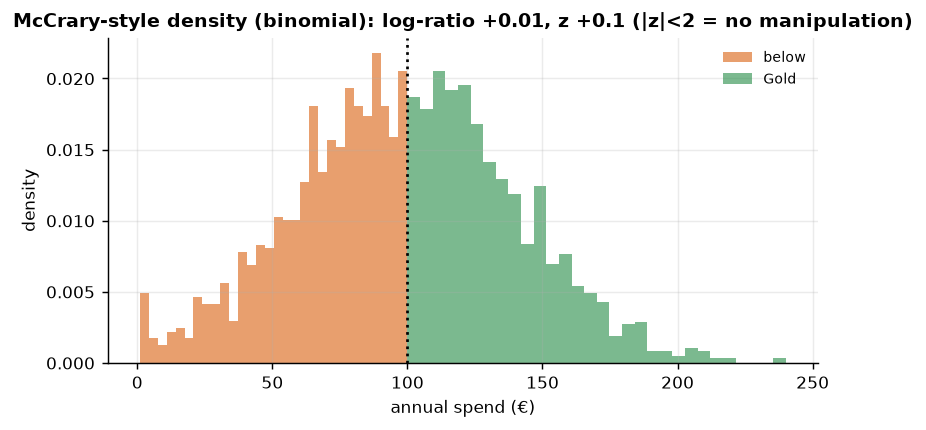

In [4]:
d_below, d_above, log_ratio, z_mcc = est.mccrary_density(df.spend.values, CUTOFF, bandwidth=15)
fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.hist(df.spend[df.spend < CUTOFF], bins=30, color=plots.ORANGE, alpha=0.6, density=True, label="below")
ax.hist(df.spend[df.spend >= CUTOFF], bins=30, color=plots.GREEN, alpha=0.6, density=True, label="Gold")
ax.axvline(CUTOFF, color="k", ls=":"); ax.set_xlabel("annual spend (€)"); ax.set_ylabel("density")
ax.set_title(f"McCrary-style density (binomial): log-ratio {log_ratio:+.2f}, z {z_mcc:+.1f} (|z|<2 = no manipulation)"); ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
print(f"density just below {d_below:.1f} vs above {d_above:.1f}, log-ratio {log_ratio:+.2f}, binomial z {z_mcc:+.2f} — "
      + ("no significant sorting across the cutoff (|z| < 2)." if abs(z_mcc) < 2 else "SIGNIFICANT pile-up — possible manipulation!"))

(The density is smooth through €100 — no suspicious pile-up of customers *just* above the cutoff — so we
have no evidence of manipulation, and the RDD comparison is fair.)

### 3c · Validity check 2 — pre-determined covariates don't jump at the cutoff

Continuity has a **second** testable implication. Anything determined *before* the perk decision —
how long the customer has been with us, how many orders they placed last year — *cannot* be caused
by it. So if we run the very same RD machinery with a **pre-determined covariate as the "outcome"**,
the estimated jump at €100 must be ≈ 0. A real jump in, say, tenure would mean the *people* just
above and just below the threshold are different people — continuity violated — exactly like an
unbalanced covariate in a botched RCT, localized to the cutoff. Together with McCrary this is the
standard falsification *pair* of applied RD (the Lee–Lemieux checklist).

Our simulated CRM has no covariates, so we create two that mirror the real-world pattern: strongly
**correlated with spend** (so they'd fool a naive comparison) but **smooth through €100 by
construction** (nothing in how they're generated knows about the cutoff — the null is true, and the
test should say so). On real CRM data you run this on *every* pre-treatment column you have and
report the whole table, like an RCT balance table.

To run the check — and later the whole Step-5 robustness battery — we need a fast, reusable
**local-linear RD fit**: plain OLS with a standard error on the jump, so every check is judged by a
*t*-statistic rather than an eyeball.

pre-determined covariate tenure_m : jump at €100 = -0.78  (t = -0.68)


pre-determined covariate n_orders : jump at €100 = +0.20  (t = +1.04)
Both |t| < 2 — covariates pass smoothly through the cutoff; the people either side are comparable.


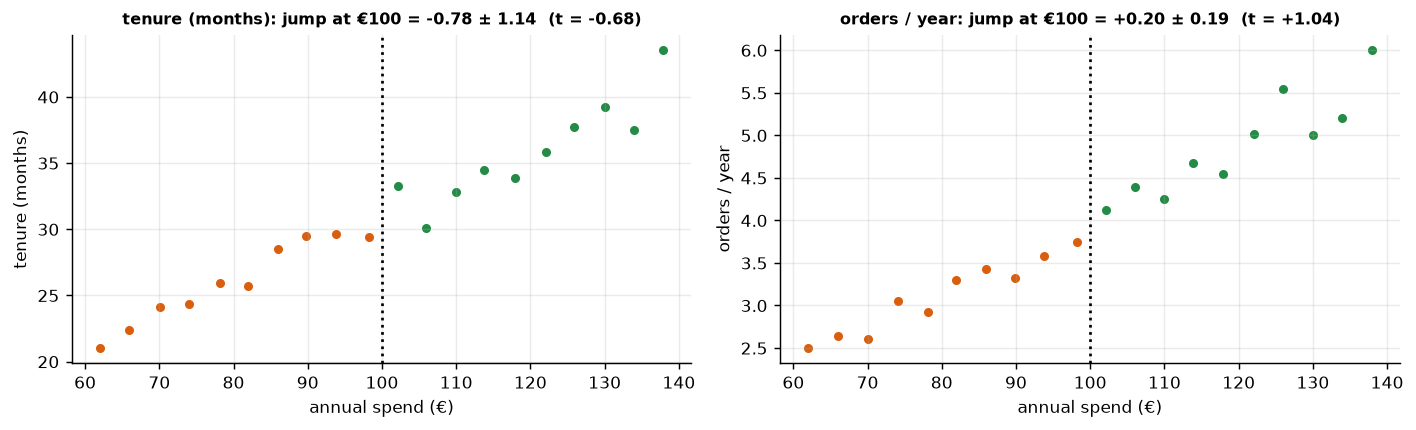

In [5]:
def rd_jump(data, cutoff, bw, order=1, ycol="retention"):
    """Local polynomial RD jump at `cutoff` within ±bw, for any outcome column
    `ycol`. Returns the estimated discontinuity (the coefficient on the 'treated'
    indicator — the jump AT the cutoff, because x is centered here) AND its
    classical OLS standard error, so any jump — real, placebo, or covariate —
    can be judged against zero with a t-stat rather than eyeballed. Reused by
    the covariate check below and the whole Step-5 robustness battery."""
    sub = data[np.abs(data.spend - cutoff) <= bw]
    x = (sub.spend - cutoff).values; tr = (sub.spend >= cutoff).astype(float).values; y = sub[ycol].values
    cols = [np.ones(len(x)), tr, x, x*tr]
    if order == 2: cols += [x**2, x**2*tr]
    D = np.column_stack(cols)
    beta, *_ = np.linalg.lstsq(D, y, rcond=None)
    resid = y - D @ beta; n, k = D.shape
    cov = (resid @ resid / max(n - k, 1)) * np.linalg.pinv(D.T @ D)
    return float(beta[1]), float(np.sqrt(max(cov[1, 1], 0.0)))   # (jump, SE of the jump)

# Two PRE-DETERMINED covariates: correlated with spend, smooth through €100 by construction.
# (Generated in-notebook — dgp.rdd_perk stays untouched; other notebooks share it.)
rng_cov = np.random.default_rng(SEED + 2)
df["tenure_m"] = np.clip(6 + 0.25 * df.spend + rng_cov.normal(0, 12, len(df)), 1, None)  # months as customer
df["n_orders"] = rng_cov.poisson(np.clip(df.spend / 25, 0.5, None)).astype(float)        # orders last year

cov_checks = {c: rd_jump(df, CUTOFF, 40, ycol=c) for c in ["tenure_m", "n_orders"]}
band = df[np.abs(df.spend - CUTOFF) <= 40].copy()
band["bin"] = pd.cut(band.spend, np.linspace(CUTOFF - 40, CUTOFF + 40, 21))
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for k, (col, lab) in enumerate([("tenure_m", "tenure (months)"), ("n_orders", "orders / year")]):
    b = band.groupby("bin", observed=True).agg(spend=("spend", "mean"), y=(col, "mean")).dropna()
    below = b.spend < CUTOFF
    ax[k].scatter(b.spend[below], b.y[below], color=plots.ORANGE, s=16)
    ax[k].scatter(b.spend[~below], b.y[~below], color=plots.GREEN, s=16)
    j, se = cov_checks[col]
    ax[k].axvline(CUTOFF, color="k", ls=":"); ax[k].set_xlabel("annual spend (€)"); ax[k].set_ylabel(lab)
    ax[k].set_title(f"{lab}: jump at €100 = {j:+.2f} ± {se:.2f}  (t = {j/se:+.2f})", fontsize=9)
fig.tight_layout()
for col, (j, se) in cov_checks.items():
    print(f"pre-determined covariate {col:9s}: jump at €100 = {j:+.2f}  (t = {j/se:+.2f})")
print("Both |t| < 2 — covariates pass smoothly through the cutoff; the people either side are comparable."
      if all(abs(j/se) < 2 for j, se in cov_checks.values())
      else "A covariate JUMPS at the cutoff — continuity is suspect; investigate before trusting any RD number.")

**How to read it.** Both covariates climb steeply with spend — Gold members *are* longer-tenured,
heavier orderers, which is precisely why the naive comparison in 2b lied — but each trend passes
**smoothly** through €100: the local-linear jump is statistically zero for both (t-stats printed
above). Combined with the clean McCrary density, this is the RD analogue of an RCT balance check — the **local-randomization** intuition in action:
in a narrow window around the cutoff, who ends up just above vs just below is as good as a coin flip, so
near the threshold *who you are* doesn't change — only Gold status does. Had tenure jumped at €100,
no amount of modelling would rescue the design; the fix is to find out *why* (account managers gaming
the tier? a billing process that rounds spend up?) — not a fancier regression.

## 4 · Estimate — Bayesian regression discontinuity

Now the estimate itself. We fit a **local linear** regression on each side of the cutoff — a straight line
for the below-€100 customers and another for the Gold customers — and the **height of the step where they
meet at €100** is the causal effect of the perk. We restrict to a **bandwidth** of ±€40 around the cutoff:
the customers near the threshold are the comparable ones (a €98 and a €102 customer are alike; a €500 whale
is not). Wider bandwidths borrow non-comparable customers; narrower ones throw away data — Step 5 checks the
answer is stable to that choice. In production you wouldn't hand-pick the window: use a plug-in optimal
bandwidth (Imbens–Kalyanaraman 2012, or the Calonico–Cattaneo–Titiunik procedure behind `rdrobust` in
R/Python), and treat the Step-5 sweep as the check that the choice doesn't matter.

**The fitted model, in symbols** (within the bandwidth $|S_i - 100| \le 40$, with
$D_i = \mathbf 1[S_i \ge 100]$):

$$
\text{retention}_i \sim \mathcal N\big(\mu_i,\; \sigma^{2}\big), \qquad
\mu_i = \beta_0 + \beta_1 S_i + \tau D_i + \beta_2\, S_i D_i,
$$

$$
\beta_0,\ \beta_1,\ \tau,\ \beta_2 \;\sim\; \mathcal N(0,\, 50^{2}), \qquad
\sigma \;\sim\; \text{HalfNormal}(1)
$$

— one straight line per side (intercepts $\beta_0$ vs $\beta_0 + \tau$, slopes $\beta_1$ vs
$\beta_1 + \beta_2$; the formula in the code, `retention ~ 1 + spend + treated + spend:treated`, is
this equation). Because spend is *uncentered*, the causal jump is **not** the raw $\tau$
coefficient: it is the gap between the two fitted lines evaluated *at the cutoff* — CausalPy's
`discontinuity_at_threshold`, the difference of predictions just above vs just below €100.

**The priors are CausalPy's defaults — and here that's fine.** The two prior lines above are exactly
what CausalPy's `LinearRegression` samples (transcribed from its source: `beta ~ Normal(0, 50)` on
every design-matrix coefficient, `y_hat_sigma ~ HalfNormal(1)` on the noise — the `NUTS: [beta,
y_hat_sigma]` line in the sampler log — visible when you run the notebook — is those two blocks). On this problem they are
effectively flat: retention lives in $[0, 1]$, so every plausible coefficient is orders of magnitude
smaller than the prior sd of 50, and a Bernoulli outcome forces $\sigma \le 0.5$, comfortably
inside HalfNormal(1). The posterior is therefore data-dominated — appropriate for a local fit whose
one job is to measure a jump, and it's why the Bayesian estimate and the OLS approximations of
Step 5 should (and do) agree. But note that "the defaults are harmless" is a statement about
**units**, not a law: score retention in percentage points (0–100) or spend in cents and you'd want
to rescale or rethink the priors.

**Owning the linear-probability choice.** Retention is Bernoulli, so fitting a straight line to a 0/1 outcome — the **linear
probability model (LPM)** — makes the Normal likelihood
misspecified twice: the true noise variance is $p(1-p)$ (heteroskedastic — it moves with $p$), and a
straight line isn't confined to $[0, 1]$. Within a ±€40 window, though, $p$ moves only a few points,
so $p(1-p)$ is nearly constant and the fitted lines stay far from the boundaries — the
misspecification is second-order, and in exchange $\tau$ reads *directly* in probability points,
the currency of Step 6's economics. The honest check is to refit with a logit link and confirm the
implied jump at the cutoff barely moves — we do exactly that right after the headline fit.


In [6]:
result = est.rdd(df[["spend","retention","treated"]], formula="retention ~ 1 + spend + treated + spend:treated",
                 running_variable_name="spend", treatment_threshold=CUTOFF, bandwidth=40.0, fast=FAST)
jump = np.asarray(result.discontinuity_at_threshold).ravel()
print(f"RD jump +{jump.mean():.1%} (true +{true_jump:.0%})  ·  90% credible interval [+{np.quantile(jump,0.05):.1%}, +{np.quantile(jump,0.95):.1%}]")
print(f"RDD convergence: {est.convergence_report(result.idata)["summary"]}")


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [beta, y_hat_sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 9 seconds.


Sampling: [beta, y_hat, y_hat_sigma]


Sampling: [y_hat]


Sampling: [y_hat]


Sampling: [y_hat]


Sampling: [y_hat]


RD jump +11.3% (true +14%)  ·  90% credible interval [+3.8%, +18.7%]
RDD convergence: max r-hat 1.000 - min ESS 1378 - divergences 0


**Reading the sampler's health check (`RDD convergence:` above).** The `+…%` headline comes with a **90% credible interval** — the range the posterior says contains the true jump with 90% probability (the Bayesian analog of a confidence interval) — plus three sampler diagnostics that say whether the MCMC sampler (the algorithm drawing samples from the posterior) actually converged. **R-hat** compares the variance within each chain to the variance across the independent chains; 1.00 is perfect and **≤ 1.01 is the usual pass bar**. **ESS** (effective sample size) is how many genuinely *independent* draws our autocorrelated chains are worth — the value printed above is far more than enough to trust a mean or interval; bigger is better. **Divergences** are steps where the sampler broke down and distrusts that region — **you want 0**. So the line above — R-hat ≈ 1.00, a healthy ESS, and 0 divergences — is clean, and we can read the posterior at face value. (Under the short FAST teaching profile R-hat can drift to ~1.02 and PyMC may print a benign *“problems during sampling”* notice; the real backstop for trusting this number is the bandwidth / placebo / polynomial robustness sweep in Step 5, not any single sampler line.)

The height of the step where the two fitted lines meet at €100 IS the estimate: +11.3% (90% CrI [+3.8%, +18.7%]).
Contrast: the naive Step-2b gap (+23.9%) compared the average heights of the two clouds instead.


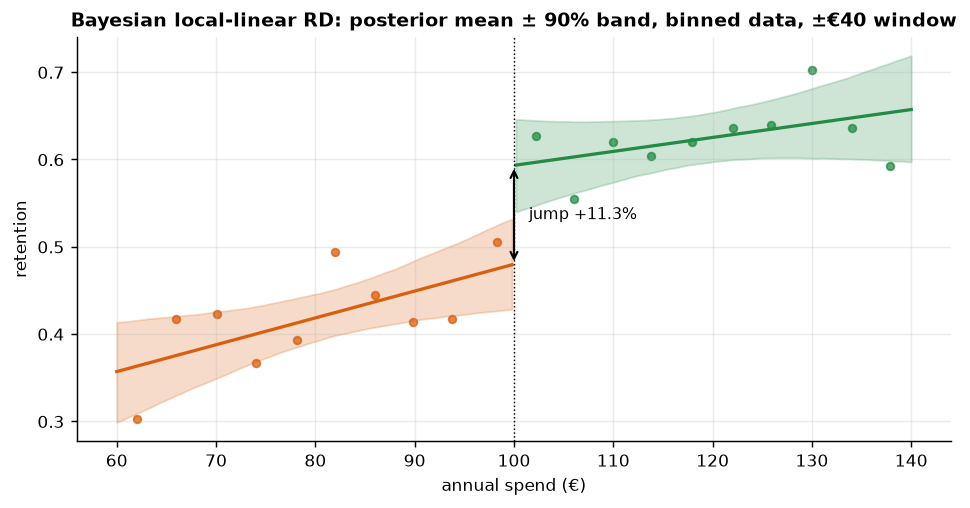

In [7]:
# --- THE canonical RD picture: the two fitted posterior lines meeting at €100 ---
bb = band.groupby("bin", observed=True).agg(spend=("spend", "mean"), ret=("retention", "mean")).dropna()
x_line = result.x_pred["spend"].values                                   # CausalPy's prediction grid (±€40)
mu_post = result.pred["posterior_predictive"]["mu"].isel(treated_units=0).stack(sample=("chain", "draw"))
line_m = mu_post.mean("sample").values
line_lo = mu_post.quantile(0.05, dim="sample").values
line_hi = mu_post.quantile(0.95, dim="sample").values
fig, ax = plt.subplots(figsize=(7.5, 4))
for side, color in [(x_line < CUTOFF, plots.ORANGE), (x_line >= CUTOFF, plots.GREEN)]:
    ax.plot(x_line[side], line_m[side], color=color, lw=1.8)
    ax.fill_between(x_line[side], line_lo[side], line_hi[side], color=color, alpha=0.22)
below_b = bb.spend < CUTOFF
ax.scatter(bb.spend[below_b], bb.ret[below_b], color=plots.ORANGE, s=18, alpha=0.75)
ax.scatter(bb.spend[~below_b], bb.ret[~below_b], color=plots.GREEN, s=18, alpha=0.75)
yb, ya = line_m[x_line < CUTOFF][-1], line_m[x_line >= CUTOFF][0]        # step endpoints at the cutoff
ax.annotate("", xy=(CUTOFF, ya), xytext=(CUTOFF, yb), arrowprops=dict(arrowstyle="<->", color="k", lw=1.2))
ax.text(CUTOFF + 1.5, (ya + yb) / 2, f"jump +{jump.mean():.1%}", fontsize=9, va="center")
ax.axvline(CUTOFF, color="k", ls=":", lw=0.8)
ax.set_xlabel("annual spend (€)"); ax.set_ylabel("retention")
ax.set_title("Bayesian local-linear RD: posterior mean ± 90% band, binned data, ±€40 window")
fig.tight_layout()
print(f"The height of the step where the two fitted lines meet at €100 IS the estimate: +{jump.mean():.1%} "
      f"(90% CrI [{np.quantile(jump, 0.05):+.1%}, {np.quantile(jump, 0.95):+.1%}]).")
print(f"Contrast: the naive Step-2b gap ({naive:+.1%}) compared the average heights of the two clouds instead.")

**This is the picture the whole method lives in.** Each dot is the average retention of a €4-wide
spend bin inside the ±€40 window; the two lines are the posterior mean of the local-linear fit on
each side, with 90% bands. **The height of the step where the two lines meet at €100 *is* the
estimate**, and the bands' separation at the cutoff is its uncertainty. Contrast this with the naive
comparison of 2b: that compared the *average height* of the orange cloud against the green cloud,
crediting the perk with the entire upward trend; RD reads only the vertical break at the threshold,
so the trend cancels. Also read the bands honestly: they are visibly wide relative to the step — that
width, not the point estimate, is what will drive the business call in Step 6.

And the promised **LPM sanity check**: refit the same window with a logit link (a likelihood that
*is* Bernoulli) and compare the implied jump in retention probability at €100.

In [8]:
import statsmodels.api as sm
sub40 = df[np.abs(df.spend - CUTOFF) <= 40]
Xl = np.column_stack([np.ones(len(sub40)), sub40.spend, sub40.treated, sub40.spend * sub40.treated])
logit_fit = sm.Logit(sub40.retention.values, Xl).fit(disp=0)
p_at = lambda s, t: logit_fit.predict(np.array([[1.0, s, t, s * t]]))[0]
logit_jump = p_at(CUTOFF, 1.0) - p_at(CUTOFF, 0.0)
print(f"Jump at €100 — linear-probability model: +{jump.mean():.1%} (Bayesian posterior mean)  ·  "
      f"logit link: {logit_jump:+.1%} — the link choice is immaterial inside a narrow window, as argued in Step 4.")

Jump at €100 — linear-probability model: +11.3% (Bayesian posterior mean)  ·  logit link: +11.2% — the link choice is immaterial inside a narrow window, as argued in Step 4.


## 5 · Validate — see the jump, plus bandwidth / placebo / polynomial robustness

A credible RD number is one that **survives** the researcher-degrees-of-freedom checks:

- **Bandwidth curve** — the estimate should be stable across a sensible range of bandwidths.
- **Placebo cutoffs** — run RD at a *grid* of fake thresholds (€60–€90 and €110–€140) where there is
  no perk; every estimated jump should be ≈ 0. A real jump at a fake cutoff would mean the method
  finds discontinuities in noise. Construction detail: below-€100 placebos use only non-Gold
  customers and above-€100 placebos only Gold customers, so no placebo window straddles the real
  jump — the standard one-sided placebo construction.
- **Polynomial order** — linear vs quadratic local fit shouldn't move the answer much. We
  deliberately stop at quadratic: Gelman & Imbens (2019) showed *high-order global* polynomials
  manufacture spurious jumps (noisy, boundary-dominated weights), which is exactly why modern RD
  practice is local-linear within a bandwidth rather than a global polynomial fit.


Bandwidth sweep: +7.2% … +14.9% across bw 15–60 (mean +12.0%) — drifts mildly but stays clearly positive.
Polynomial: linear +11.3%, quadratic +10.9%.
Placebo grid (jump, t): €60 +2.5% (t=+0.34), €70 +0.6% (t=+0.09), €80 +3.0% (t=+0.47), €90 +1.4% (t=+0.18), €110 -4.8% (t=-0.66), €120 +3.5% (t=+0.58), €130 +5.8% (t=+0.90), €140 -9.7% (t=-1.33)
Largest placebo |t| = 1.33 (at €140) — all 8 placebos statistically indistinguishable from zero; the real €100 jump's 90% CrI [+3.8%, +18.7%] excludes zero.


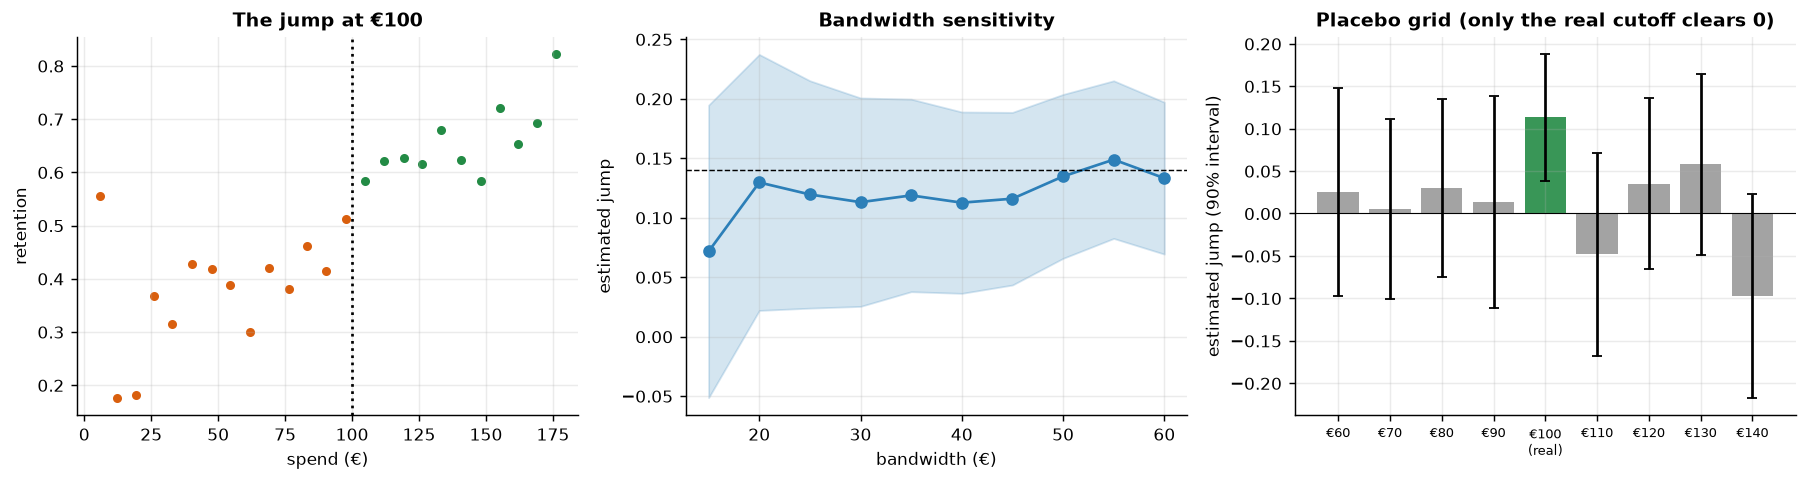

In [9]:
# rd_jump (local-linear OLS with SE on the jump) was defined in §3c and is reused here.
bws = np.arange(15, 61, 5)
jb = [rd_jump(df, CUTOFF, b) for b in bws]                 # (jump, SE) per bandwidth
by_bw = [e for e, _ in jb]; by_se = [s for _, s in jb]     # keep SEs for the uncertainty band
# Placebo GRID: fake cutoffs €60–€90 fitted on non-Gold customers only, €110–€140 on Gold only,
# ±€25 windows — the side restriction keeps every placebo window clear of the real €100 jump.
below_cuts, above_cuts = [60, 70, 80, 90], [110, 120, 130, 140]
placebos = {c: rd_jump(df[df.spend < CUTOFF], c, 25) for c in below_cuts}
placebos.update({c: rd_jump(df[df.spend >= CUTOFF], c, 25) for c in above_cuts})
poly = {"linear": rd_jump(df, CUTOFF, 40, 1), "quadratic": rd_jump(df, CUTOFF, 40, 2)}
z90 = 1.645

fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
# binned scatter
bins = np.linspace(df.spend.min(), min(df.spend.max(), 180), 26); df["bin"] = pd.cut(df.spend, bins)
b = df.groupby("bin", observed=True).agg(spend=("spend","mean"), ret=("retention","mean")).dropna()
below = b.spend < CUTOFF
ax[0].scatter(b.spend[below], b.ret[below], color=plots.ORANGE, s=16); ax[0].scatter(b.spend[~below], b.ret[~below], color=plots.GREEN, s=16)
ax[0].axvline(CUTOFF, color="k", ls=":"); ax[0].set_xlabel("spend (€)"); ax[0].set_ylabel("retention"); ax[0].set_title("The jump at €100")
# bandwidth curve
ax[1].plot(bws, by_bw, color=plots.BLUE, marker="o"); ax[1].axhline(true_jump, color="k", ls="--", lw=0.8)
ax[1].fill_between(bws, np.array(by_bw)-z90*np.array(by_se), np.array(by_bw)+z90*np.array(by_se), color=plots.BLUE, alpha=0.2)
ax[1].set_xlabel("bandwidth (€)"); ax[1].set_ylabel("estimated jump"); ax[1].set_title("Bandwidth sensitivity")
# placebo grid WITH 90% intervals — real cutoff = CausalPy posterior CI; placebos = local-linear ±1.645·SE
real_lo, real_hi = np.quantile(jump, 0.05), np.quantile(jump, 0.95)
cuts_order = below_cuts + [100] + above_cuts
labels = [f"€{c}" if c != 100 else "€100\n(real)" for c in cuts_order]
vals   = [placebos[c][0] if c != 100 else jump.mean() for c in cuts_order]
err_lo = [z90*placebos[c][1] if c != 100 else jump.mean()-real_lo for c in cuts_order]
err_hi = [z90*placebos[c][1] if c != 100 else real_hi-jump.mean() for c in cuts_order]
colors = [plots.GREY if c != 100 else plots.GREEN for c in cuts_order]
ax[2].bar(labels, vals, yerr=[err_lo, err_hi], capsize=3, color=colors, alpha=0.9)
ax[2].tick_params(axis="x", labelsize=7)
ax[2].axhline(0, color="k", lw=0.6); ax[2].set_ylabel("estimated jump (90% interval)"); ax[2].set_title("Placebo grid (only the real cutoff clears 0)")
fig.tight_layout()
placebo_t = {c: placebos[c][0] / placebos[c][1] for c in placebos}
c_max = max(placebo_t, key=lambda c: abs(placebo_t[c])); max_t = abs(placebo_t[c_max])
print(f"Bandwidth sweep: +{min(by_bw):.1%} … +{max(by_bw):.1%} across bw {bws.min()}–{bws.max()} "
      f"(mean +{np.mean(by_bw):.1%}) — drifts mildly but stays clearly positive.")
print(f"Polynomial: linear +{poly['linear'][0]:.1%}, quadratic +{poly['quadratic'][0]:.1%}.")
print("Placebo grid (jump, t): " + ", ".join(f"€{c} {placebos[c][0]:+.1%} (t={placebo_t[c]:+.2f})" for c in cuts_order if c != 100))
print(f"Largest placebo |t| = {max_t:.2f} (at €{c_max}) — all {len(placebos)} placebos statistically indistinguishable "
      f"from zero; the real €100 jump's 90% CrI [+{real_lo:.1%}, +{real_hi:.1%}] excludes zero.")

**How to read the robustness battery.** *Left* — bin retention by spend and you can *see* the step at €100
sitting on top of the smooth "big spenders retain more" trend; that step is the perk effect. *Middle* — the
estimate **drifts mildly** with the bandwidth (narrow windows are noisier, wider ones pull in curvature) but
stays clearly positive and brackets the truth across the whole range, so we're not cherry-picking a window.
*Right* — the decisive check, now a **grid of eight fake cutoffs with 90% intervals**: re-run the same
local-linear RD at €60–€90 (non-Gold customers only) and €110–€140 (Gold only), where no perk switches.
The point estimates wobble around zero — one or two bars always *look* sizeable (with eight draws from
noise, they should!), but read each bar's *interval*, not its height: every placebo interval comfortably
spans zero and every |t| is under 2, with the largest flagged in the printout so you can check it rather
than trust us. Only the **real** €100 cutoff has an interval that **excludes** zero. That is the honest
test — a *family* of t-stats, not an eyeball. Together with the McCrary density, the covariate-continuity
check, and the linear-vs-quadratic agreement, it's the full case that the jump is a real causal effect,
not an artefact of how we drew the lines.

*(Implementation note: for speed, the battery's refits are local-linear **OLS approximations** of the same specification, judged on frequentist t-stats; the headline €100-cutoff estimate itself stays fully Bayesian.)*


### 5b · Recovery across many seeds — unbiased *and* calibrated?

A single sample can land a little off; the real test is whether the estimator is **centred on the truth over repeated samples** and whether its 90% interval **covers** the truth at the stated rate. We refit on many fresh samples (a small fast fit each) and check both.

RD jump across 25 seeds: mean +13.8% (true +14%)  bias -0.2%  sd 4.3%  ·  90% CI covers truth in 23/25 seeds — near-nominal calibration.


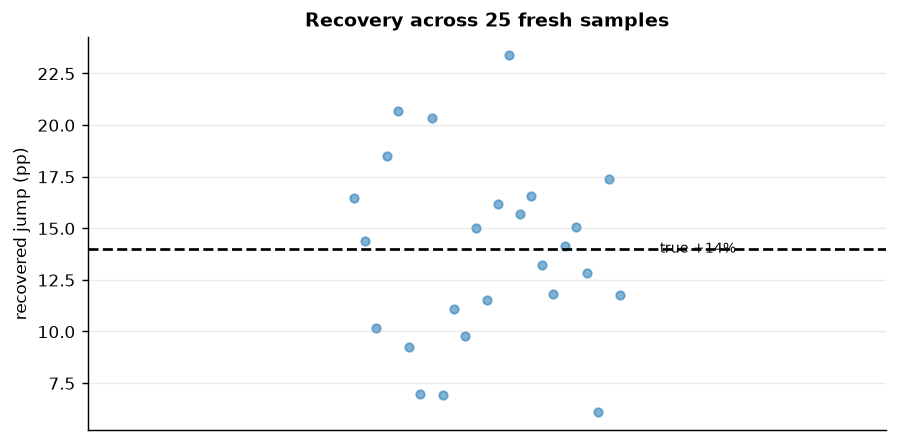

In [10]:
# --- Recovery across many seeds: does the RD jump recover +14pp and cover it? (fast OLS local-linear) ---
NSEED = 12 if FAST else 25
pts = []; cov = 0; z90 = 1.645
for sd in range(NSEED):
    d, tj = dgp.rdd_perk(n=2500, cutoff=CUTOFF, true_jump=TRUE, seed=200 + sd)
    d["treated"] = d["treated"].astype(int)
    j, se = rd_jump(d, CUTOFF, 40, 1)
    pts.append(j); cov += int(abs(j - tj) <= z90 * se)
pts = np.array(pts)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.scatter(np.linspace(-0.2, 0.2, NSEED), pts * 100, s=22, color=plots.BLUE, alpha=0.6)
ax.axhline(TRUE * 100, color="k", ls="--"); ax.text(0.26, TRUE * 100, f"true +{TRUE:.0%}", fontsize=8, va="center")
ax.set_xticks([]); ax.set_xlim(-0.6, 0.6); ax.set_ylabel("recovered jump (pp)")
ax.set_title(f"Recovery across {NSEED} fresh samples"); fig.tight_layout()
print(f"RD jump across {NSEED} seeds: mean +{pts.mean():.1%} (true +{TRUE:.0%})  bias {pts.mean()-TRUE:+.1%}  "
      f"sd {pts.std():.1%}  ·  90% CI covers truth in {cov}/{NSEED} seeds — near-nominal calibration.")

## 6 · Decide, in euros — does the perk pay, and where to set the cutoff?

Value the retention lift: extra retained customers × annual value, minus the perk cost, **at the
current €100 margin** (that's what RD identifies). We also sweep the perk cost to find the
break-even.

> **What RD can and can't answer.** RD identifies *only* the local effect at the €100 margin — it tells us whether the perk pays **there**, but it **cannot** tell us where to set the cutoff (moving the threshold extrapolates beyond the RD's local validity; that question needs an experiment or multi-cutoff data).
>
> **Two stated inputs.** `N_AT_MARGIN ≈ 3,000` is an illustrative count of members inside the ±€40 window around €100 per cycle — swap in your CRM's number; the **0.9** go/no-go bar is the cookbook's convention for "sure enough to act without a further test".

Net €7.7/member  ·  total €22,960 [90% €-22,140, €67,444]
P(perk pays) 0.80 → reconsider  ·  break-even perk cost ≈ €8/member (conservative).
Perk-cost sweep €0–30: P(perk pays) falls 0.99 → 0.21; at the actual €15 cost P(pays) = 0.80, E[net] = €8/member (break-even €8).


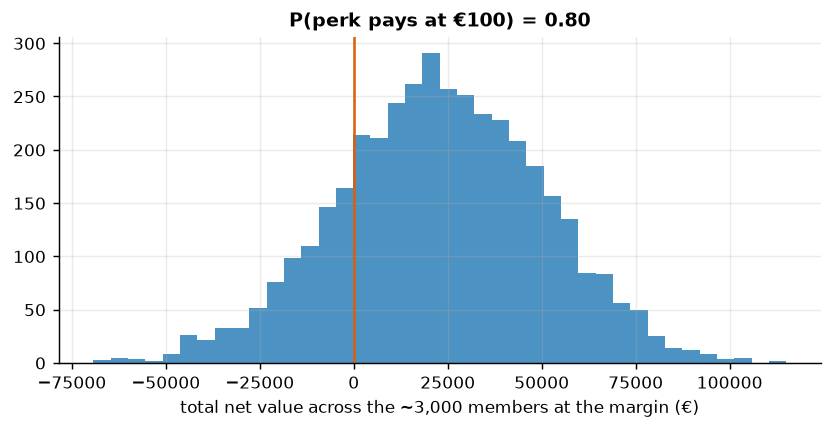

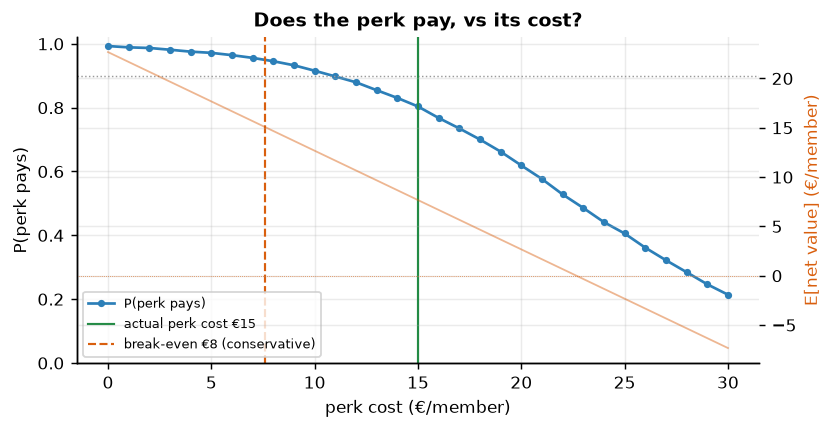

In [11]:
ANNUAL_VALUE, PERK_COST, N_AT_MARGIN = 200.0, 15.0, 3000
value = jump * ANNUAL_VALUE - PERK_COST
total = value * N_AT_MARGIN
p_worth = (value > 0).mean()
be_perk = np.quantile(jump, 0.05) * ANNUAL_VALUE      # perk cost the effect can bear (conservative)
fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.hist(total, bins=40, color=plots.BLUE, alpha=0.85); ax.axvline(0, color=plots.ORANGE, lw=1.4)
ax.set_xlabel("total net value across the ~3,000 members at the margin (€)"); ax.set_title(f"P(perk pays at €100) = {p_worth:.2f}"); fig.tight_layout()
print(f"Net €{value.mean():.1f}/member  ·  total €{total.mean():,.0f} [90% €{np.quantile(total,0.05):,.0f}, €{np.quantile(total,0.95):,.0f}]")
print(f"P(perk pays) {p_worth:.2f} → " + ("KEEP the perk at the €100 margin" if p_worth>0.9 else "reconsider") +
      f"  ·  break-even perk cost ≈ €{be_perk:.0f}/member (conservative).")

# --- Perk-cost sweep (promised above): P(perk pays) and E[net value] vs the perk's cost.
#     RD identifies ONLY the local effect at €100, so this sizes the decision AT THIS MARGIN. ---
perk_grid = np.linspace(0, 30, 31)
gross = jump * ANNUAL_VALUE                        # posterior of gross retention value / member at the €100 margin
p_pays = np.array([(gross > pc).mean() for pc in perk_grid])
e_net  = gross.mean() - perk_grid                  # E[net value] / member at each perk cost
figc, axc = plt.subplots(figsize=(6.5, 3.4))
axc.plot(perk_grid, p_pays, color=plots.BLUE, marker="o", ms=3, label="P(perk pays)")
axc.axhline(0.9, color=plots.GREY, ls=":", lw=0.8)
axc.axvline(PERK_COST, color=plots.GREEN, lw=1.2, label=f"actual perk cost €{PERK_COST:.0f}")
axc.axvline(be_perk, color=plots.ORANGE, ls="--", lw=1.2, label=f"break-even €{be_perk:.0f} (conservative)")
axc.set_xlabel("perk cost (€/member)"); axc.set_ylabel("P(perk pays)"); axc.set_ylim(0, 1.02)
axc.set_title("Does the perk pay, vs its cost?"); axc.legend(fontsize=7, loc="lower left")
axt = axc.twinx(); axt.plot(perk_grid, e_net, color=plots.ORANGE, alpha=0.45, lw=1.0)
axt.axhline(0, color=plots.ORANGE, lw=0.4, ls=":"); axt.set_ylabel("E[net value] (€/member)", color=plots.ORANGE)
figc.tight_layout()
print(f"Perk-cost sweep €0–30: P(perk pays) falls {p_pays[0]:.2f} → {p_pays[-1]:.2f}; at the actual €{PERK_COST:.0f} "
      f"cost P(pays) = {(gross > PERK_COST).mean():.2f}, E[net] = €{gross.mean()-PERK_COST:.0f}/member (break-even €{be_perk:.0f}).")

**How to read the decision histogram.** Mass to the right of the orange zero line = P(perk pays); the wide spread — *not* the positive mean — is what makes this a *reconsider / TEST* call.

**And the sweep turns it into a negotiation.** At the actual €15 perk cost, P(pays) comes out around 0.8 (printed above) — real
but below the 0.9 bar — while the *conservative* break-even (the cost the 5th-percentile effect
still covers) sits in the €6–8/member range (exact value printed above). So the decision isn't "keep or kill": it's **either bring the perk's
cost toward the break-even** (a cheaper perk with the same salience keeps the retention jump and clears the
bar by construction) **or buy more certainty before renewing** — a longer measurement horizon or a
wider eligibility window around the cutoff, both of which tighten the jump posterior. What the
sweep must *not* be used for is moving the €100 threshold itself: RD's evidence is local to the
customers near €100 (the blockquote above), and pricing a new cutoff from this posterior would be
extrapolation dressed as analysis.

How much certainty would more data actually buy? The next cell quantifies it — the last input
the memo needs.

In [12]:
# --- Value of information: the jump posterior's sd shrinks ≈ 1/sqrt(n in window). What would more data buy?
#     (normal approximation to the posterior of gross €/member; same posterior mean assumed to hold) ---
from scipy.stats import norm
n_bw = int((np.abs(df.spend - CUTOFF) <= 40).sum())
m_g, s_g = gross.mean(), gross.std()                       # posterior of gross € value per marginal member
p_now = float((gross > PERK_COST).mean())
p_2x = float(norm.cdf((m_g - PERK_COST) / (s_g / np.sqrt(2))))     # ~2x window members = one more cycle
sd_req = (m_g - PERK_COST) / norm.ppf(0.9)                 # posterior sd that puts P(pays) at exactly 0.9
factor = (s_g / sd_req) ** 2 if sd_req > 0 else float("inf")
print(f"Members in the ±€40 window this cycle: {n_bw:,}  ·  P(perk pays €{PERK_COST:.0f}) now: {p_now:.2f}")
print(f"One more cycle of data (≈ 2x the window sample): CrI ≈ 29% tighter → P(pays) ≈ {p_2x:.2f} if the mean holds.")
print(f"Clearing the 0.9 bar at the current cost needs posterior sd €{s_g:.1f} → €{sd_req:.1f}/member, "
      f"i.e. ≈ {factor:.1f}x the window sample — which is why renegotiating the perk's cost is the stronger lever.")

Members in the ±€40 window this cycle: 1,706  ·  P(perk pays €15) now: 0.80
One more cycle of data (≈ 2x the window sample): CrI ≈ 29% tighter → P(pays) ≈ 0.88 if the mean holds.
Clearing the 0.9 bar at the current cost needs posterior sd €9.1 → €6.0/member, i.e. ≈ 2.3x the window sample — which is why renegotiating the perk's cost is the stronger lever.


### The one-paragraph decision

> **To the CMO.** The Gold perk causes a real retention lift for customers at the €100 margin —
> a jump of roughly ten percentage points (exact posterior printed in Step 4), an estimate that
> survives a density check, covariate continuity, eight placebo cutoffs, bandwidth and polynomial
> sweeps, and a multi-seed calibration study. At the current €15/member cost it pays *in
> expectation* (order €20k per cycle across the ~3,000 marginal members), but the probability it
> pays is only ≈ 0.8 — below our 0.9 action bar. So: **don't kill it, and don't blindly renew it.**
> Either (a) renegotiate the perk's cost down toward the conservative break-even printed in Step 6 —
> the cost even the 5th-percentile effect covers, which clears the bar by construction — or (b) buy
> certainty: the value-of-information readout above shows one more cycle of margin data tightens the
> interval ~30% and lifts P(pays) toward the bar *if the point estimate holds*, while clearing 0.9
> outright at the current cost would take several times the data. Cost renegotiation is the stronger
> lever; more data is the fallback.
>
> **And the threshold question the title poses?** RD alone **cannot** answer "where should the
> threshold be": it measures the effect at €100 and nothing in the data distinguishes a constant
> jump from one that decays away from the cutoff — formally, $\tau(s)$ is identified only at
> $s = c$ (our DGP happens to make it constant; a real perk needn't be). The design answer: **randomize
> the cutoff** — a tier experiment assigning €90 / €100 / €110 thresholds across regions or cohorts
> traces $\tau(s)$ at three points and prices the threshold directly; failing that, a past threshold
> change gives a second cutoff for a multi-cutoff RD. Moving the threshold on the strength of one
> local estimate would be extrapolation dressed as analysis.

## 7 · Caveats

- **RD is *local*.** The effect is identified only *at the cutoff* — the perk's effect on customers
  near €100, not on your €500 whales. Don't extrapolate the jump to everyone.
- **Manipulation breaks it.** We checked the McCrary density and covariate continuity; watch for heaping
  at round numbers. If the observations *nearest* the threshold are suspect (heaping, gamed baskets),
  the standard remedy is a **donut RD** — drop observations within ±ε of the cutoff and refit
  (CausalPy exposes this as `donut_hole`).
- **Bandwidth is bias–variance.** The estimate drifts mildly with the window (narrow = noisier, wide =
  more curvature) but stays clearly positive here; an estimate that *swings across zero* with bandwidth
  would be a red flag.
- **Fuzzy RD if the rule isn't sharp.** If crossing €100 only *raises the probability* of Gold
  (grandfathering, overrides), use the fuzzy-RD ratio (jump in Y ÷ jump in P(treated)) — this ratio is exactly the Wald/IV estimator of notebook 11, with the threshold acting as the instrument (estimand formalized in Step 3).